# LeiGS 2026 – Proctor Prediction Challenge: Getting Started Notebook

> Author: Hermann Busse, M.Sc., HTWK Leipzig - Institut für Geotechnik, 2026-05

## Notebook Overview

This notebook provides a solid baseline for the **LeiGS 2026 Proctor Prediction Challenge**. It demonstrates the complete modelling workflow from exploratory data analysis (EDA) through to generating a valid submission.

To keep the code concise, complex operations are factored out into `helper_functions.py`.

**<u>Notebook chapters follow the typical steps of model development:</u>**

**Workflow:**
1. Setup
2. Data Import & First Overview
3. Exploratory Data Analysis (EDA): Understanding Targets and Feature Distributions
4. Feature Engineering: Deriving Predictive Features
5. Model Selection
6. Model Training: Cross-Validation & Pipeline Comparison
7. Empirical Validation: Korfiatis (1982) vs. ML
8. Explainability: SHAP Analysis
9. Prediction on Test Set & Submission
10. Recommendations for Further Data Experiments

**Notation:**
* 🚨 **Critical Note:** Methodological pitfalls.
* 💡 **Methodology Tip:** State-of-the-art approaches and background knowledge.
* 🛠️ **Action:** Starting points for your own optimisations.

The Kaggle website offers many additional [notebook tutorials](https://www.kaggle.com/learn) covering various data analysis and model development strategies.
If you are new to programming, you will find a good introductory tutorial for Python [here](https://www.kaggle.com/learn/intro-to-programming).
____

## 1. Setup

### Importing Libraries

Before we start the analysis, we load the required libraries.

> **💡 Installation (Local)**: If you are running this notebook locally, dependencies need to be installed once. To do so, run the following cell once (remove the `#` at the beginning of the line).

In [1]:
# Run once to install all required packages.
# Remove the '#' and execute this cell – then comment it out again.

# %pip install matplotlib numpy pandas scipy seaborn scikit-learn statsmodels shap

In [2]:
import matplotlib.pyplot as plt  # basic plotting functions
import numpy as np  # numerical computations / arrays
import pandas as pd  # for working with tabular data and data manipulation
from pathlib import Path  # for working with file paths
import seaborn as sns  # statistical plotting built on matplotlib

### 📂 Importing helper_functions and custom functions

The file `helper_functions.py` contains project-specific helper functions for this notebook.

In [3]:
import importlib  # for reloading modules, e.g. after changes to helper_functions.py
import helper_functions  # custom functions, e.g. for plotting or computing the metric

# Re-run this line every time you change helper_functions.py to apply the updates in the notebook:
importlib.reload(helper_functions)
from helper_functions import calculate_nmae

### 🧬 Reproducibility (Global Seed) & Language

In research and competitions, the **reproducibility** of experiments is essential. Many algorithms (e.g. data splits, model initialisations) use pseudo-random processes. Without controlling these random numbers, results vary with every run, making it impossible to compare different model iterations.

In [4]:
from helper_functions import CFG

CFG.lang = "en"
CFG.seed_everything(43)
SEED = CFG.seed  # Alias for sklearn compatibility (random_state=SEED)


Random seed set to 43 for reproducibility.


___

## 2. Data Import & First Overview

We load the competition data and get a first overview. The pipeline automatically detects whether the notebook is running locally or directly on the Kaggle platform.

* **`train.csv`**: Contains the laboratory parameters (features) of all tests as well as the target variables (`proctor_mdd_g_cm3`, `proctor_owc_pct`). Used for model training and validation.
* **`test.csv`**: Contains only the features. Final predictions must be generated for these samples.
* **`sample_submission.csv`**: Defines the exact format for the leaderboard submission.

In [5]:
importlib.reload(helper_functions)
from helper_functions import load_and_summarize_data

# Initialisierung und Seed-Setzung
CFG.seed_everything(CFG.seed)
print(f"Nutze Datenverzeichnis: {CFG.data_dir.resolve()}")

# Daten laden & Übersicht anzeigen
train_df, test_df, submission_df = load_and_summarize_data(
    data_dir=CFG.data_dir,
    lang=CFG.lang
)

Zufallsseed auf 43 gesetzt für Reproduzierbarkeit.
Nutze Datenverzeichnis: /kaggle/input/competitions/leigs-2026-proctor-prediction-challenge
DataFrames successfully loaded:
  - Train: 201 rows, 25 columns
  - Test:  87 rows, 23 columns
  - Sub:   87 rows, 3 columns


## 3. Exploratory Data Analysis (EDA): Understanding Targets and Feature Distributions

### Training Data - Getting an Overview

Before we train models, we need to understand the data structure. The `train.csv` contains:

* **Metadata:** `id` (unique sample identifier)
* **Particle Size Distribution (PSD):** `psd_size_at_d10_mm` to `d98_mm` (cumulative passing values), `psd_has_sedimentation` (sedimentation analysis available?), and mass fractions `< 2mm`, `< 0.063mm`, `< 0.002mm`.
* **Atterberg Limits:** `atterberg_liquid_limit_pct` ($w_L$), `atterberg_plastic_limit_pct` ($w_P$).
* **Loss on Ignition:** `loss_on_ignition_pct`
* **Hydraulic Parameters:** `hyd_cond_kf_m_s` ($k_f$), `hyd_cond_hyd_gradient`
* **Grain Density:** `grain_density_g_cm3` ($\rho_s$).
* **Proctor Parameters:** `proctor_diam_mm` (mold diameter).
* 🎯 **Target Variables:** `proctor_mdd_g_cm3` (Maximum Dry Density) & `proctor_owc_pct` (Optimum Water Content).


> **💡 Modelling Concept:**
> Our algorithm learns the relationships between the **features** in order to predict the **target variables** for unknown samples.

___

The DataFrame structure lets you explore the data with simple commands. Here are a few examples:

**Basic information:**

In [6]:
# 1. First look at the raw data (first 3 rows are usually sufficient)
display(train_df.head(3))

# 2. Check structure, data types and missing values
print("\n--- DataFrame Info ---")
train_df.info()

,id,psd_size_at_d10_mm,psd_size_at_d20_mm,psd_size_at_d30_mm,psd_size_at_d40_mm,psd_size_at_d50_mm,psd_size_at_d60_mm,psd_size_at_d70_mm,psd_size_at_d80_mm,psd_size_at_d90_mm,...,psd_passing_at_2mm_pct,proctor_mdd_g_cm3,proctor_owc_pct,proctor_diam_mm,grain_density_g_cm3,hyd_cond_kf_m_s,hyd_cond_hyd_gradient,atterberg_liquid_limit_pct,atterberg_plastic_limit_pct,loss_on_ignition_pct
0,0,0.136773,0.315214,0.547515,0.933930,1.788142,3.313938,7.214010,12.517275,20.160863,...,51.68,2.068,8.06,150,2.650,NaN,NaN,NaN,NaN,NaN
1,1,0.014579,0.062060,0.119258,0.221877,0.423550,1.022249,2.978369,6.081199,10.622063,...,65.49,2.037,10.42,100,2.690,NaN,NaN,NaN,NaN,1.3
2,2,0.003243,0.022301,0.087024,0.156595,0.217595,0.323793,0.512853,1.546115,10.921905,...,81.40,2.051,10.94,100,2.722,1.400000e-10,30.0,26.45,13.75,NaN



--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           201 non-null    int64  
 1   psd_size_at_d10_mm           201 non-null    float64
 2   psd_size_at_d20_mm           201 non-null    float64
 3   psd_size_at_d30_mm           201 non-null    float64
 4   psd_size_at_d40_mm           201 non-null    float64
 5   psd_size_at_d50_mm           201 non-null    float64
 6   psd_size_at_d60_mm           201 non-null    float64
 7   psd_size_at_d70_mm           201 non-null    float64
 8   psd_size_at_d80_mm           201 non-null    float64
 9   psd_size_at_d90_mm           201 non-null    float64
 10  psd_size_at_d95_mm           201 non-null    float64
 11  psd_size_at_d98_mm           201 non-null    float64
 12  psd_has_sedimentation        201 non-null    bool   
 

We can see that `psd_has_sedimentation` is a boolean feature that indicates with [True/False] whether a sedimentation analysis is present. The features `proctor_diam_mm` and `id` are read as integers (int64), and the other columns as floating-point numbers (float64).

___

**Statistical Summary**

In [7]:
# 3. Descriptive statistics (transposed .T for better readability)
display(train_df.describe().T)

,count,mean,std,min,25%,50%,75%,max
id,201.0,100.000000,58.167861,0.000000e+00,5.000000e+01,1.000000e+02,150.000000,200.000000
psd_size_at_d10_mm,201.0,0.124623,0.134850,5.000000e-06,4.178000e-03,9.019100e-02,0.220670,0.760737
psd_size_at_d20_mm,201.0,0.252619,0.368777,4.000000e-05,1.980400e-02,2.369700e-01,0.354247,4.338920
psd_size_at_d30_mm,201.0,0.434801,0.729432,3.500000e-04,5.005300e-02,3.660390e-01,0.530757,8.338219
psd_size_at_d40_mm,201.0,0.746744,1.210754,2.392000e-03,1.219490e-01,4.984110e-01,0.812382,10.716752
psd_size_at_d50_mm,201.0,1.314316,2.021663,5.385000e-03,2.037570e-01,6.427790e-01,1.429613,13.773777
psd_size_at_d60_mm,201.0,2.308311,3.285563,1.253600e-02,2.917540e-01,8.235280e-01,3.169510,17.097726
psd_size_at_d70_mm,201.0,3.856856,5.129706,2.540400e-02,4.473950e-01,1.145870e+00,7.042005,21.672247
psd_size_at_d80_mm,201.0,6.231906,7.494571,4.051500e-02,8.012810e-01,2.115362e+00,11.872687,30.779061
psd_size_at_d90_mm,201.0,10.547194,10.900280,6.794600e-02,1.884620e+00,4.977963e+00,20.250492,44.015107


____

### Data Manipulation & Visual Inspection

With **Pandas**, patterns and anomalies in the data can be quickly isolated and visualised.

In [8]:
# 1. Filtering with .query() (clean syntax)
high_owc_df = train_df.query("proctor_owc_pct > 15")[['proctor_owc_pct']]  # Example: extract all samples with optimum water content > 15%
print(f"1) Number of samples with OWC > 15%: {len(high_owc_df)}\n")

# 2. Extract extreme values
print("2) Top 3 samples with the highest dry density:")
display(train_df.nlargest(3, 'proctor_mdd_g_cm3'))  # alternatively: nsmallest() for the lowest values

# 3. Visual data inspection in the DataFrame (Pandas styling)
print("3) Visual inspection of the first 8 samples for selected features:")
styled_df = (train_df[["proctor_mdd_g_cm3", "proctor_owc_pct", "atterberg_plastic_limit_pct"]]
             .head(8)
             .style
             .bar(subset=['proctor_mdd_g_cm3'], color="#279611")
             .highlight_null(color='red')
             .background_gradient(cmap='Blues', subset=['proctor_owc_pct']))

display(styled_df)

1) Number of samples with OWC > 15%: 23

2) Top 3 samples with the highest dry density:


,id,psd_size_at_d10_mm,psd_size_at_d20_mm,psd_size_at_d30_mm,psd_size_at_d40_mm,psd_size_at_d50_mm,psd_size_at_d60_mm,psd_size_at_d70_mm,psd_size_at_d80_mm,psd_size_at_d90_mm,...,psd_passing_at_2mm_pct,proctor_mdd_g_cm3,proctor_owc_pct,proctor_diam_mm,grain_density_g_cm3,hyd_cond_kf_m_s,hyd_cond_hyd_gradient,atterberg_liquid_limit_pct,atterberg_plastic_limit_pct,loss_on_ignition_pct
105,105,0.073290,0.236969,0.394425,0.662231,1.304559,4.654899,14.802655,20.415482,26.599767,...,54.05,2.209,5.72,150,2.69,NaN,NaN,NaN,NaN,NaN
153,153,0.220670,0.418051,0.866519,2.274199,5.595488,10.185479,16.461200,23.481740,34.902261,...,38.81,2.199,6.65,150,2.65,NaN,NaN,NaN,NaN,NaN
58,58,0.131005,0.286911,0.477811,0.812382,1.536789,3.037918,6.666096,11.872687,20.001425,...,53.74,2.194,7.30,150,2.67,NaN,NaN,NaN,NaN,NaN


3) Visual inspection of the first 8 samples for selected features:


,proctor_mdd_g_cm3,proctor_owc_pct,atterberg_plastic_limit_pct
0,2.068000,8.060000,nan
1,2.037000,10.420000,nan
2,2.051000,10.940000,13.750000
3,1.648000,20.310000,22.440000
4,1.820000,15.760000,nan
5,2.056000,10.130000,nan
6,2.110000,8.280000,nan
7,1.744000,9.910000,nan


### Data Completeness & Missing Values

In [9]:
from helper_functions import get_missing_data_report  # import function for analysing missing data

missing_report = get_missing_data_report(train_df).sort_values(by='missing_pct', ascending=False)  # output missing data report, sorted by percentage of missing values

print("Report: Missing values in the training data")
display(missing_report)

Report: Missing values in the training data


,missing_count,missing_pct,dtype
atterberg_liquid_limit_pct,175,87.064677,float64
atterberg_plastic_limit_pct,175,87.064677,float64
hyd_cond_kf_m_s,140,69.651741,float64
hyd_cond_hyd_gradient,140,69.651741,float64
loss_on_ignition_pct,140,69.651741,float64


A look at the data reveals gaps for certain features:
- **Complete:** Particle size distribution (PSD) and the Proctor target values (`MDD`, `OWC`).
- **Partially missing (sparse):** Atterberg limits, loss on ignition, and hydraulic conductivity parameters.

> **💡 Methodology Tip (Missing Values):** Missing values in an ML context are often *informative*. The absence of Atterberg limits phenomenologically indicates a non-plastic (coarse-grained) soil for which the test is not applicable. Blindly filling (imputing) with means would be a technical error here. Notes on imputation follow in later sections.

___

### Target Variable Distributions

We analyse the target variables `proctor_mdd_g_cm3` (Maximum Dry Density) and `proctor_owc_pct` (Optimum Water Content) statistically and visually.

> **💡 Excursus: Boxplot**
> The box marks the middle 50 % of the data (interquartile range), the line inside marks the median. The "whiskers" show the regular spread. Points outside mark extreme values/outliers, which can be particularly challenging for model training.

--- Statistical Summary of Targets ---


,count,mean,std,min,25%,50%,75%,max
proctor_owc_pct,201.0,10.087264,3.364756,3.540,7.730,9.460,11.59,20.710
proctor_mdd_g_cm3,201.0,1.972383,0.140286,1.609,1.882,1.993,2.08,2.209


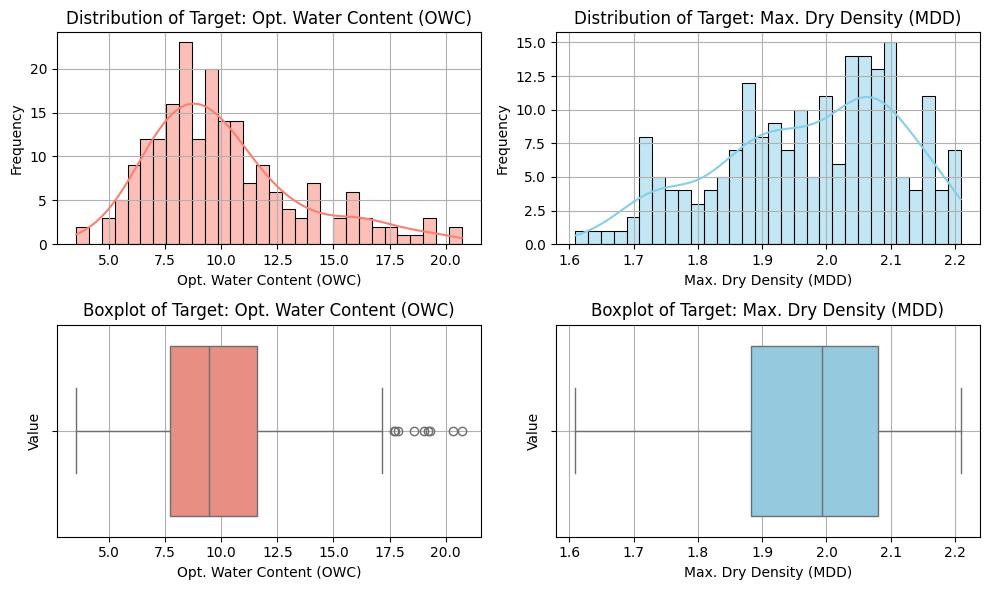

In [10]:
from helper_functions import plot_target_distributions

# 1. Global definition of target variables
target_cols = ["proctor_owc_pct", "proctor_mdd_g_cm3"]

# 2. Statistical summary
print(CFG.get_label('stat_summary_targets'))
display(train_df[target_cols].describe().T)

# 3. Visualise distributions (delegated to helper_functions)
plot_target_distributions(train_df, target_cols, CFG)

#### Technical Interpretation of the Distributions:

* **Optimum Water Content (OWC):** The distribution is markedly right-skewed. The median lies at around 10 %. The middle 50 % of the data (the box in the boxplot) sits compactly in the range of approximately 8 % to 12.5 %. This spectrum is typical for primarily coarse-grained soils. The prominent upper outliers (values > 17.5 % up to over 20 %) represent fine-grained, plastic soils (clays/silts) or high organic content, whose large specific surface area binds significantly more water.

* **Maximum Dry Density (MDD):** Values range from approximately 1.55 to 2.25 g/cm³ with a median just below 2.0 g/cm³. The distribution (KDE curve) is slightly asymmetric and indicates a weak multimodality. Densities > 2.0 g/cm³ indicate well-graded gravels/sands. The pronounced lower outlier (< 1.60 g/cm³) in the boxplot technically corresponds to the high OWC values and marks samples with a high fines or organic content.

### Zero Air Voids (ZAV) Curve & Plausibility Check

The theoretical Zero Air Voids curve ($S_r = 100\,\%$) represents the physical upper limit of dry density for a given water content and specific grain density ($G_s$). It is reached when all pores are completely water-filled:

$$\rho_{d(\text{sat } 100\%)} = \frac{G_s}{1 + \frac{w}{100} \cdot G_s}$$

We verify the physical plausibility of our Proctor optima by comparing them against the theoretical ZAV curves, and then analyse the distribution of grain densities.

> **🚨 Critical Data Note (Imputation Artefact):**  A massive spike at exactly 2.65 g/cm³ (standard value for quartz) indicates that this value is often **assumed** rather than individually measured in laboratory practice. Such artefacts are typical of real-world datasets and require special attention during feature engineering or model selection, as they degrade the signal-to-noise ratio.

In [ ]:
from helper_functions import plot_kde_and_scatter, plot_grain_density_distribution

# 1. Combined scatter & KDE plot
plot_kde_and_scatter(train_df, CFG)

# 2. Isolated plot to identify the 2.65 artefact
plot_grain_density_distribution(train_df, CFG)

#### Technical Interpretation of the Plausibility Check

The overlaid theoretical ZAV curve provides the physical reference frame for our target variables:

* **ZAV Curve Check:** The data points fall almost exclusively below the ZAV lines ($G_s = 2.65$), as expected. This confirms that the measured Proctor optima (MDD/OWC) are physically plausible. The few points that slightly exceed this boundary can be explained by locally higher actual grain densities.
* **The 2.65 Artefact:** The grain density distribution reveals a severe anomaly: an extremely large number of samples have exactly the value 2.65 g/cm³. Technically, this corresponds to the standard value for quartz-rich soils. In laboratory practice, this prominent peak means that this value is often **assumed by default** for time reasons rather than individually measured.
* **Extreme grain density values:**
  * Values **> 2.70 g/cm³** indicate admixtures of heavy minerals (e.g. iron-bearing) or specific clay minerals.
  * Values **< 2.55 g/cm³** (lower outliers) strongly indicate **organic constituents** (such as humus or peat), as these have a significantly lower density than mineral soils.

> **🛠️ Action (Feature Engineering):** Such imputation artefacts (like the massive spike at 2.65) degrade the signal for a machine learning algorithm. It is legitimate and often effective to treat such synthetic laboratory values critically in subsequent steps or to derive a separate categorical feature from them (e.g. `is_standard_grain_density = True/False`).

____

### Feature Analysis

We examine the distributions of the independent features to understand their influence on the target variables. The laboratory parameters include:
* Particle size distributions (PSD)
* Atterberg limits (plasticity)
* Hydraulic conductivity & loss on ignition


In [ ]:
# 1. Statistical summary of all features (excluding target variables)
print(CFG.get_label('stat_summary_features'))
display(train_df.drop(columns=target_cols).describe().T)


___

### Particle Size Distribution (PSD)

The particle size distribution curve forms the core of geotechnical soil classification. A steep curve indicates a narrow (uniform) grading, while a flat curve indicates broadly graded material.

> **🚨 Critical Methodology Note (The Extrapolation Trap):**
> The feature `psd_has_sedimentation` indicates whether the fines fraction (< 0.063 mm) was genuinely measured (True) or only extrapolated (False).
> In the plot, we have **deliberately only highlighted in red those curves** that lack sedimentation analysis **and** simultaneously have a significant fines content (> 10 %). For these samples, the exact split between clay and silt may be erroneous due to the assumption of logarithmic extrapolation.
>
> **🛠️ Action (Feature Engineering):** As an alternative to semi-logarithmic extrapolation,

In [ ]:
from helper_functions import plot_psd_curves, get_psd_segmentation_counts

# Display segments
display(get_psd_segmentation_counts(train_df, CFG))

# Plot grain size distributions
plot_psd_curves(train_df, CFG)

### Extracting Key Parameters & Multicollinearity of PSD Features

The 11 breakpoints of the particle size distribution (`psd_size_at_...`) describe the grain skeleton in great detail. However, they are mathematically strongly interdependent (cumulative curve), leading to **multicollinearity**. This can destabilise models (particularly linear ones).

> **💡 Methodology Tip (Feature Extraction):**
> Instead of throwing all 11 highly correlated breakpoints into the model, we draw on geotechnical domain knowledge. We aggregate the curve into three classical key parameters:
> * **$d_{50}$:** Mean grain diameter (primary soil type).
> * **$C_U$ (Coefficient of Uniformity):** $d_{60}/d_{10}$ (breadth of grading).
> * **$C_C$ (Coefficient of Curvature):** $d_{30}^2 / (d_{60} \cdot d_{10})$ (shape of the curve).
>
> *Note: Computing $C_U$ and $C_C$ requires $d_{10}$. These values are partly based on extrapolated data (see above).*

In [ ]:
from helper_functions import plot_correlation_heatmap, plot_psd_params

# 1. Correlation heatmap of raw sieve breakpoints
psd_cols = [c for c in train_df.columns if c.startswith('psd_size_at_')]
plot_correlation_heatmap(train_df, psd_cols, CFG)

# 2. Visualise established PSD key parameters (feature engineering preview)
plot_psd_params(train_df, CFG)


#### Technical Interpretation of the PSD Parameters

* **Primary soil type ($d_{50}$):** The dataset is dominated by **sands** ($0.063 - 2.0$ mm).
* **Grading ($C_U$ & $C_C$):** The scatter plots show a clear bipartition. A large portion of the samples exhibits a technically well-graded structure ($C_U \geq 6$, $1 \leq C_C \leq 3$), which promises high Proctor densities. The massive outliers to the right ($C_U > 30$) originate from strongly mixed-grain or fine-grained soils.

### Bivariate Analysis: Influence of $C_U$ and $C_C$ on the Proctor Optima

We examine the direct interactions between the PSD parameters and the target variables. Since fine-grained soils are primarily compacted through their plasticity (Atterberg limits), we isolate **coarse-grained, clean soils (fines content $\le 5\,\%$) using a filter mask** to analyse the purely physical packing effects of the grain skeleton.

> **💡 Methodology Tip (Non-linear Relationships):**
> The correlations almost completely disappear when the filter mask is removed. This is due to the fine-grained samples (which are not primarily governed by grain packing → Atterberg) and the fact that artificially extrapolated $d_{10}$ values generate extreme outliers in $C_U$. Within the physically valid mask, however, an inverse ($a/x + b$) or logarithmic fit describes the saturation effect of grain packing (pore space filling) far better than a linear approach.

> * **Linearisation for linear models:** If linear algorithms (e.g. Ridge/Lasso) are used, a log-transformation of $C_U$ is mandatory.
> * **Tree-based models:** Algorithms such as *Random Forests* or *XGBoost* can natively represent these strongly non-linear, mask-dependent interactions.

In [ ]:
from helper_functions import add_gradation_parameters, plot_feature_vs_proctor_optima

# 1. Feature Engineering: Compute C_U and C_C (centralised function)
train_df = add_gradation_parameters(train_df)

# 2. Define filter mask for clean, coarse-grained soils
coarse_mask = (
    (train_df["psd_has_sedimentation"] == False) & 
    (train_df["psd_passing_at_0_063mm_pct"] <= 5) & 
    (train_df["psd_C_U"] < 30) & 
    (train_df["psd_C_C"] < 3)
)
filtered_df = train_df[coarse_mask]

# 3. Bivariate regression plots with marginal distributions
plot_feature_vs_proctor_optima(filtered_df, feature_col="psd_C_U", cfg=CFG)
plot_feature_vs_proctor_optima(filtered_df, feature_col="psd_C_C", cfg=CFG)

#### Technical Interpretation of the Regression Analyses:

1. **Coefficient of Uniformity $C_U$ (breadth of grading):**
   * **Maximum dry density ($\rho_{d,pr}$):** Shows a strong positive trend ($r \approx 0.80$). The more broadly graded the sand, the higher the density, as smaller particles perfectly fill the voids.
   * **Optimum water content ($w_{pr}$):** Shows a clear negative trend ($r \approx -0.60$). Well-graded grain skeletons have a lower pore volume and therefore less capacity to absorb water.

2. **Coefficient of Curvature $C_C$ (shape of the curve):**
   * Within the narrowly bounded, filtered range ($C_C < 1.4$), the picture shifts to a moderate negative trend for density. This shows that $C_C$ is not a linear global predictor, but that its effect is strictly coupled to the soil type.

The bivariate analysis reveals a striking anomaly: some samples exhibit a surprisingly low dry density ($\rho_{d,pr} < 2.0\,\text{g/cm}^3$) despite high uniformity ($C_U > 15$).


**🛠️ Root Cause Analysis: Outliers or Not?**

> **💡 Implications for Modelling:**

> * **Linear models:** Linear regressors (Ridge/Lasso) fail completely on such anomalous clusters, as they rigidly assume a monotonically increasing trend. Only complex interaction terms or prior clustering can help here (explicit generation of features that isolate prominent subgroups, e.g. `is_outlier_cluster = True/False` or `C_U_is_lower_than_3`).

> * **Tree-based models (Random Forest / XGBoost):** These algorithms excel here. Through combinations of PSD parameters and individual fractions (e.g. `psd_passing_at_2mm_pct`), they can autonomously detect and mathematically isolate the specific conditions for gap-graded soils.

In [ ]:
from helper_functions import plot_psd_outliers

# 1. Run plot and obtain index-aligned mask
is_outlier_mask = plot_psd_outliers(train_df, CFG)

# 2. Extract affected samples (check for gap-graded soils)
outlier_samples = train_df[is_outlier_mask]
print(f"Targeted inspection of the {len(outlier_samples)} identified anomaly samples:")
display(outlier_samples[['id', 'psd_C_U', 'proctor_mdd_g_cm3', 'psd_passing_at_0_063mm_pct', 'psd_passing_at_2mm_pct']])


### Methodological Parameters: Proctor Mold Diameter

The choice of mold diameter (`proctor_diam_mm`) is not an intrinsic soil property, but a methodological decision by the laboratory based on the maximum grain size of the sample:

* **100 mm (Standard):** Mostly used for fine-grained soils and pure sands (maximum grain size $\le 16\,\text{mm}$).
* **150 mm (Large):** Used for gravelly, coarse-grained soils (maximum grain size up to $31.5\,\text{mm}$).

> **🚨 Correlation vs. Causation (Data Leakage):**
> The mold size does *not cause* higher densities. It is, however, an extremely strong proxy for the presence of coarse grain. The model learns here "150 mm mold = coarse soil = tendency toward higher density".

> **🛠️ Action (Oversize Correction):** If a soil contains stones that are too large, they are often sieved out in practice. The Proctor optima are then determined on the remaining fine material and subsequently scaled up mathematically to the total soil (oversize correction per DIN 18127). It is worth checking in feature engineering whether the maximum grain sizes documented in the PSD match the mold, or whether "corrected" target values are present that behave physically differently.

In [ ]:
from helper_functions import plot_categorical_impact

# 1. Count mold sizes
diam_counts = train_df["proctor_diam_mm"].value_counts().to_frame(CFG.get_label('count'))
print(CFG.get_label('count_diam'))
display(diam_counts)

# 2. Visual comparison: target variables depending on mold size
plot_categorical_impact(train_df, category_col="proctor_diam_mm", cfg=CFG)

### Air Void Ratio ($n_a$): The Physical Guardrail

Using the grain density ($\rho_s$), the physical plausibility of the Proctor measurements ($w_{pr}$ and $\rho_{d,pr}$) can be validated. From the geotechnical three-phase system, the remaining air void ratio ($n_a$) at the optimum is calculated as follows:

$$n_a = 1 - \frac{\rho_{d,pr}}{\rho_s} - \frac{w_{pr}}{100} \cdot \frac{\rho_{d,pr}}{\rho_w}$$

**Geotechnical rule of thumb:** For well-graded soils, the Proctor optimum typically lies at approximately $5\,\%$ air void ratio. The line connecting the optima runs nearly parallel to the theoretical ZAV curve ($n_a = 0\,\%$).

> **Note on the figure:** In the left plot, the $n_a$ isobars (lines of equal air void ratio) were calculated using the standard value $\rho_s = 2.65\,\text{g/cm}^3$. For the exact distribution in the right plot, the individual grain density of each sample was used.

In [ ]:
from helper_functions import analyze_proctor_air_voids

# 1. Run analysis and plot
eval_df, stats_df, _ = analyze_proctor_air_voids(train_df, CFG)

# 2. Display statistical summary of the air void ratio
print(CFG.get_label('stat_summary_airvoids'))
display(stats_df)


#### Technical Interpretation & Implications for Modelling:

* **Plausibility confirmed:** The median air void ratio lies at a realistic **5.2 %**. The majority of the optima follow exactly the course of the theoretical $5\,\%$ isobar.

* **Physical outliers:** Points to the left of the ZAV curve ($n_a < 0\,\%$) are physically impossible. No sample lies in this range (right plot). Some samples exhibit high air void ratios (> 10 %), which requires investigation.

> **🚨 Warning (Target Leakage):**
> Since $n_a$ is calculated from the two target variables to be predicted ($w_{pr}$ and $\rho_{d,pr}$), it is unknown on the test dataset and **must not be used as a feature (input variable)**.

**🛠️ Sanity Check (Data Cleaning):** We filter the training set. Impossible values ($n_a < 0\,\%$) or extreme outliers ($n_a > 12\,\%$) are flagged as erroneous or removed.
___

### Hydraulic Conductivity ($k_f$)

The feature `hyd_cond_kf_m_s` describes the water permeability of the soil. Since this spans several orders of magnitude in nature, a transformation to $\log_{10}(k_f)$ is mandatory for visualisations and linear ML models.

> **🚨 Critical ML Note (Target Leakage vs. Kaggle "Legal Leak"):**
> From a geotechnical perspective, $k_f$ is often measured in the laboratory *after* Proctor compaction on the final test specimen. This means $k_f$ is causally dependent on the target variable (MDD). In a real prediction scenario, $k_f$ should therefore not be used. **However, since this feature is provided in the `test.csv` for this competition, it is a strong predictor ("Legal Leak").**
>
> **The Problem (Sparsity):** Approximately 70 % of values are missing. The model must therefore be able to handle missing data robustly (e.g. XGBoost / LightGBM), or we need an extremely good imputation strategy (e.g. via fines content).

**Sanity Check & Distribution:**
We project the transformed $k_f$ values against the standardised permeability bands per DIN. This allows us to visually validate the plausibility of the measurements.

In [ ]:
from helper_functions import plot_permeability_zones, plot_feature_vs_proctor_optima

# 1. Feature Engineering: Safe log-transformation (catch zero values)
train_df['log10_kf'] = np.log10(train_df['hyd_cond_kf_m_s'].replace(0, np.nan))

# 2. Plot distribution across geotechnical zones
plot_permeability_zones(train_df, col_k="hyd_cond_kf_m_s", cfg=CFG)


The distribution is **bimodal** with peaks in the clayey-silty range ($\approx 10^{-10}$ m/s) and the sandy range ($\approx 10^{-4}$ m/s). Let us now check whether the feature is correlated:

In [ ]:
# 3. Regression analysis (uses our function from the previous section)
# Since log10_kf has been computed, we pass it directly.
plot_feature_vs_proctor_optima(train_df, feature_col="log10_kf", cfg=CFG)

**Finding:** A visible trend emerges – more permeable soils (sands/gravels) tend to achieve higher maximum dry densities and require less water.

#### Multicollinearity & Interactions (Hazen Relationship)
According to Hazen ($k_f \approx C \cdot d_{10}^2$), permeability is physically strongly coupled to the particle size distribution. We check this redundancy (multicollinearity) in a heatmap and analyse the non-linear interaction between fines content and permeability.

In [ ]:
from helper_functions import plot_correlation_heatmap, plot_interaction

# 1. Column selection for multicollinearity check (incl. log10_kf)
# psd_size_at_d10_mm: Hazen reference grain size AND anchor feature in the model.
# psd_C_U = d60/d10: encodes gradation more compactly than raw sieve breakpoints (no d50 needed).
analysis_cols = [
    'psd_size_at_d10_mm', 'psd_C_U', 'psd_passing_at_0_063mm_pct',
    'psd_C_C', 'log10_kf', 'proctor_mdd_g_cm3', 'proctor_owc_pct'
]

# 2. Heatmap: Are the features redundant?
plot_correlation_heatmap(train_df, analysis_cols, cfg=CFG)

# 3. Interaction: How does k_f depend on fines content and how does density behave within it?
plot_interaction(
    train_df,
    x="psd_passing_at_0_063mm_pct",
    y="hyd_cond_kf_m_s",
    hue="proctor_mdd_g_cm3",
    cfg=CFG
)


#### Technical Interpretation of the Interactions

The visualisations confirm the strong correlation between $k_f$ and the PSD parameters, in particular the effective grain diameter $d_{10}$. This leads to two important findings:

1. **Multicollinearity (Heatmap):** The hydraulic conductivity ($\log_{10} k_f$) correlates strongly with the PSD parameters. This means that $k_f$ only brings limited "new" information to a model, as the flow behaviour is already defined by the pore network (grain skeleton).

2. **The Hazen Analogy (Scatter plot):** According to Hazen, permeability is proportional to the square of the effective grain diameter ($k_f \propto d_{10}^2$). In our interaction plot (on log scales), we see the exact mirror image: with increasing fines content (< 0.063 mm), permeability drops exponentially. The overlay of Proctor density ($\rho_d$, colour coding) also shows that dense packings are achieved almost exclusively in the transition zone at moderate $k_f$ values ($\approx 10^{-6}$ to $10^{-4}$ m/s).

> **🛠️ Action (Feature Selection & Engineering):**
> * **Linear models (Ridge, Lasso):** Linear algorithms often fail with strong non-linearities. It is essential to manually construct interaction terms. Based on Hazen, you could create a synthetic feature such as `log_d10_squared = np.log10(d10**2)` to ease the model's task.
> * **Tree-based models (Random Forest, XGBoost):** These algorithms can natively learn non-linear thresholds (like the steep drop in the scatter plot).
> * **Drop vs. Keep:** Due to the massive sparsity (70 % missing $k_f$ values) and potential *target leakage*, it is a valid strategy to completely remove the hydraulic features from the dataset. Models trained exclusively on the robust, comprehensive PSD primary data often generalise better on new (test) data.

### Atterberg Limits: Plasticity and Covariate Shift

For fine-grained soils, plasticity is a decisive indicator of compactability. In the **Casagrande chart**, the plasticity index ($I_P = w_L - w_P$) is plotted against the liquid limit ($w_L$).

* **A-Line** ($I_P = 0{.}73 \cdot (w_L - 20)$): Theoretically separates clays (above) from silts (below).
* **U-Line** ($I_P = 0{.}9 \cdot (w_L - 8)$): Empirical upper bound. Points above this are physically barely possible and indicate measurement errors.

> **💡 Methodology Tip (Testing for Covariate Shift):**
> A common reason for ML model failure on the leaderboard is a "domain shift" – when the test data exhibits completely different properties from the training data. We deliberately plot the test data (grey) on top of the training data (coloured by fines content) to visually validate whether the model will later interpolate in familiar territory or will have to dangerously extrapolate.

In [ ]:
from helper_functions import plot_casagrande

# 1. Casagrande chart incl. test data overlay
plot_casagrande(
    train_df, 
    cfg=CFG,
    test_df=test_df, 
    hue_col="psd_passing_at_0_063mm_pct"
)

### Loss on Ignition

Loss on ignition is a simple indicator of organic content or other mass losses due to intense heating. In geotechnical datasets, it can help classify unusual samples. High organic content typically leads to lower dry densities and higher optimum water contents, since organic particles have a large specific surface area and can bind much more water.

In [ ]:
from helper_functions import analyze_and_plot_ignition_loss, plot_feature_vs_proctor_optima

# 2. Distribution of loss on ignition
analyze_and_plot_ignition_loss(train_df, cfg=CFG)

# 3. Regression analysis: LOI vs. target variables
plot_feature_vs_proctor_optima(train_df, feature_col="loss_on_ignition_pct", cfg=CFG)

#### Technical Summary & Implications for ML:
* **Strong signal:** Despite the fact that loss on ignition was only measured for a fraction of the samples (sparsity), it shows an extremely high correlation with the target variables (especially with $w_{pr}$).

* **Modelling strategy:** A linear algorithm requires a smart imputation of the missing values (e.g. imputing with $0\,\%$ if the particle size distribution points to pure sand). Gradient Boosting Trees (XGBoost/LightGBM) can internally handle sparse data (NaNs) extremely well and directly exploit this strong signal.

## 4. Feature Engineering: Deriving Predictive Features

"Feature engineering" describes the transformation of raw data into informative, model-ready signals. This includes creating, combining, or reducing features based on data analysis and physical domain knowledge.

We use a simple **Linear Regression** as the test model here. Why? Linear algorithms are extremely sensitive to scaling, multicollinearity, and hidden interactions. They are therefore the perfect "seismograph" for potential pitfalls in feature selection and transformation.
We use the Mean Absolute Error (MAE) within 10-fold cross-validation as the metric.

> **🚨 Preparation (Handling NaNs):** Linear models cannot process missing values (NaNs). For this isolated test, we therefore use **only the complete, gap-free PSD features**. Advanced imputation for all other features ($k_f$, Atterberg, LOI) follows in the next section.

Baseline & Log-Diff Feature Construction

In [ ]:
from helper_functions import calculate_vif

# 1. Isolate only fully populated PSD columns for this test
psd_cols = [col for col in train_df.columns if col.startswith("psd_size_at_")]
base_cols = psd_cols + ["psd_C_U", "psd_C_C"]

# Temporary DataFrame without NaN values for model comparison with linear models
df_test = train_df.dropna(subset=base_cols + target_cols).copy()

# 2. Feature Engineering: Logarithmic differences (slope of the grading curve)
# log(d_i+1) - log(d_i) = log(d_i+1 / d_i) -> Quantifies the fraction width
df_test[psd_cols] = df_test[psd_cols].replace(0, np.nan)  # catch zero values

log_diff_cols = []
for i in range(len(psd_cols) - 1):
    col_name = f"log_diff_{psd_cols[i+1].replace('psd_size_at_', '')}"
    df_test[col_name] = np.log10(df_test[psd_cols[i+1]]) - np.log10(df_test[psd_cols[i]])
    log_diff_cols.append(col_name)

# Anchor feature: d10 as absolute position reference for the grading curve (as in the model pipeline)
anchor_col = "psd_size_at_d10_mm"
features_diff_with_anchor = log_diff_cols + [anchor_col]

# 3. Check multicollinearity (VIF)
print(CFG.get_label('vif_analysis'))

vif_raw           = calculate_vif(df_test, psd_cols)["VIF"].mean()
vif_diff_anchored = calculate_vif(df_test, features_diff_with_anchor)["VIF"].mean()

print(f"{CFG.get_label('vif_mean_raw')} {vif_raw:.0f} (Extreme Collinearity)")
print(f"{CFG.get_label('vif_mean_diff')} {vif_diff_anchored:.2f} (Substantially more stable)")


The Variance Inflation Factor (VIF) analysis shows: the original cumulative breakpoints are extremely redundant (VIF >>> 10). The new log-differences drastically reduce collinearity and better capture the physical structure of the sample.

As an alternative, we test **Principal Component Analysis (PCA)**. It bundles variance into a few mathematically uncorrelated principal components.

> **🚨 Kaggle Best Practice (Preventing Data Leakage):**
> Data transformations such as scaling and PCA must **not** be applied to the entire dataset before cross-validation. The PCA would otherwise "see" the signal from the validation folds (leakage). We therefore use an `sklearn.pipeline.Pipeline` in which the PCA is computed strictly in isolation within each fold.

In [ ]:
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from helper_functions import plot_feature_engineering_comparison, test_with_model

# RidgeCV automatically selects the optimal regularisation parameter α via
# Leave-One-Out-CV on the respective training set → fair comparison,
# as each feature configuration finds its own optimum.
_ALPHAS = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]

def _make_pipeline():
    """New, independent RidgeCV pipeline for each comparison run."""
    return Pipeline([("scaler", StandardScaler()), ("reg", RidgeCV(alphas=_ALPHAS))])

# Three classic geotechnical key grain sizes as the minimal model
key_sieves = ["psd_size_at_d10_mm", "psd_size_at_d50_mm", "psd_size_at_d90_mm"]

# Comparison: increasing information content from left (minimal) to right (maximal)
scores = {
    "Few Key Sizes\n(d\u2081\u2080, d\u2085\u2080, d\u2089\u2080)": test_with_model(
        df_test[key_sieves + target_cols],
        model=_make_pipeline(), seed=CFG.seed
    ),
    "Full\nGrading Curve": test_with_model(
        df_test[psd_cols + target_cols],
        model=_make_pipeline(), seed=CFG.seed
    ),
    "Grading Curve\n+ C_U & C_C": test_with_model(
        df_test[psd_cols + ["psd_C_U", "psd_C_C"] + target_cols],
        model=_make_pipeline(), seed=CFG.seed
    ),
    "Grading Curve + Log-Diff\n(Slope + Anchor)": test_with_model(
        df_test[psd_cols + log_diff_cols + ["psd_C_U", "psd_C_C"] + target_cols],
        model=_make_pipeline(), seed=CFG.seed
    ),
}

plot_feature_engineering_comparison(scores, cfg_class=CFG, figsize=(14, 6))


### 📊 Interpretation of Results

The plot impressively demonstrates how strongly the data representation influences the prediction quality of a linear algorithm:

1. **The Baseline:** The raw, cumulative PSD breakpoints (left) provide a working basis despite high multicollinearity, but are mathematically unstable.
2. **Domain Features:** Explicitly adding the established uniformity and curvature coefficients ($C_U, C_C$) already reduces the prediction error slightly, since the model can barely learn these highly non-linear ratios from linear data on its own.

3. **PCA (Dimensionality Reduction):** Although we compressed the information from 11 breakpoints down to just 3 principal components, the error remains stable or even decreases slightly. PCA effectively eliminates noise and collinearity, but sacrifices interpretability.

4. **🏆 The Winner (Log-Diff):** The physically motivated Log-Diff approach adds valuable information. By considering the slope (fraction widths), we defuse multicollinearity (see VIF) while retaining features that can be physically linked directly to compactability.

> **💡 Implications for the Final Pipeline:**
> We will incorporate the `Log-Diff` approach as well as $C_U$ and $C_C$ as fixed building blocks in our feature engineering pipeline. In the next step, however, we must address the core problem of this dataset: **imputing the missing values** (Atterberg, permeability, organic content).


💡 Optionally, the fractions can also be computed:

* **Clay (< 0.002 mm):** $pct_{Clay} = pct_{\le 0.002mm}$
* **Silt (0.002 - 0.063 mm):** $pct_{Silt} = pct_{\le 0.063mm} - pct_{\le 0.002mm}$
* **Sand (0.063 - 2.0 mm):** $pct_{Sand} = pct_{\le 2.0mm} - pct_{\le 0.063mm}$
* **Gravel (> 2.0 mm):** $pct_{Gravel} = 100\% - pct_{\le 2.0mm}$


In [ ]:
from helper_functions import prepare_features

train_df = prepare_features(train_df)
print(f"✅ train_df extended: {train_df.shape[1]} columns  |  {train_df.shape[0]} samples")
print(f"   New fraction columns: psd_fraction_clay/silt/sand/gravel")
print(f"   New log-diff columns: log_diff_psd_size_at_d20..d98_mm")

### Imputation of Missing Values

In [ ]:
missing_cols = [col for col in train_df.columns if train_df[col].isna().any()]
print(f"Columns with missing values ({len(missing_cols)}):")
print(missing_cols)


The analysis shows gaps for Atterberg limits, hydraulic conductivity ($k_f$), and loss on ignition. The missing patterns are technically justifiable and should not be ignored:

1. **Atterberg Limits (MNAR – Missing Not At Random):** Coarse-grained soils (sand, gravel) are generally non-plastic. The test is physically not applicable – the absence is not random, but a system-information. We explicitly encode this state via a binary indicator column (`atterberg_is_missing`) and rule-based set the limit values of coarser samples (fines content < 15 %) to 0. However, there are also individual samples which according to their grain distribution should rather be described by their plastic properties. These are missing at random (MAR).

2. **$k_f$ value & Loss on Ignition (MAR – Missing At Random):** Often missing for project or cost reasons, not due to the sample itself. Imputation is justified here.

**Strategy:** We use **Multivariate Iterative Imputation (MICE)** with an ExtraTreesRegressor as the base estimator. MICE iteratively estimates missing values from the other features, which is far better suited for strongly correlated geotechnical data than simple mean imputation. **Important:** Imputers are strictly refitted per fold within the cross-validation loop (fold isolation) to prevent data leakage.

In [ ]:
from helper_functions import impute_missing_values

cols_for_imputation = [
    'grain_density_g_cm3', 'psd_C_U', 'psd_C_C',
    'atterberg_liquid_limit_pct', 'atterberg_plastic_limit_pct',
    'loss_on_ignition_pct', 'hyd_cond_kf_m_s', 'hyd_cond_hyd_gradient' 
]

# Corrected variable passing: target_cols, seed and cfg_class
df_imputed = impute_missing_values(
    train_df.copy(), 
    columns_for_imputation=cols_for_imputation, 
    target_cols=target_cols, 
    seed=CFG.seed,
    cfg_class=CFG
)

The diagnostic plot below visually verifies our two-step imputation strategy. Blue points show the untouched laboratory measurements. Orange crosses ($\times$) represent values mathematically estimated via MICE for cohesive soils. Red dots ($\bullet$) show granular, coarse-grained samples that were rule-based set physically exactly to $0.0\%$ plasticity to prevent artificial bias in the model.

In [ ]:
from helper_functions import visualize_imputation_strategies

# Clean call by passing before/after state
visualize_imputation_strategies(
    df_raw=train_df,       # State BEFORE imputation
    df_imputed=df_imputed, # State AFTER imputation
    feature_missing="atterberg_liquid_limit_pct",
    feature_ref="proctor_owc_pct",
    cfg_class=CFG
)

### Feature Engineering Based on Filled Data: Plasticity and Interaction

From the (now complete) Atterberg limits we calculate physically highly relevant index quantities:

1. **Plasticity Index ($PI$):** $PI = w_L - w_P$. Describes the range of the plastic state.
2. **Skempton Activity ($A$):** $A = \frac{PI}{m_{\text{clay}}}$. Characterises the swelling and shrinkage potential of the clay minerals.
3. **Hazen Proxy ($d_{10}^2$):** According to Hazen, hydraulic conductivity is proportional to the square of the effective grain diameter. We explicitly pass this physical term to the model.

In [ ]:
from helper_functions import add_plasticity_interaction_features, evaluate_imputation_impact

# Save state directly after MICE before new features are computed
df_imputed_initial = df_imputed.copy()

# Step 1: Compute geotechnical interaction features
df_imputed = add_plasticity_interaction_features(df_imputed)

# Step 2: Quantify the effect of imputation on model error
mae_mdd_base, mae_owc_base, mae_mdd_imp, mae_owc_imp, mae_mdd_all, mae_owc_all = evaluate_imputation_impact(
    train_df,
    df_imputed_initial,
    df_imputed,
    target_cols=target_cols,
    seed=CFG.seed,
    cfg_class=CFG,
)

### Feature Scaling & Transformation

Classic algorithms (Ridge, SVMs, neural networks) are sensitive to very different value ranges. If the sand fraction lies between 0 and 100, while the hydraulic conductivity $k_f$ operates in the range of $10^{-5}$ m/s, unscaled raw data substantially distorts linear models.

We build a customised **`ColumnTransformer`** with three transformation paths:

| Scaler | When appropriate | Examples |
|---|---|---|
| `PowerTransformer` (Yeo-Johnson) | Strongly right-skewed distributions | $C_U$, $k_f$, $d_{10}$–$d_{60}$ |
| `RobustScaler` | Geotechnical measurements with expected outliers | Grain density $\rho_s$, loss on ignition |
| `StandardScaler` | Unremarkable, approximately normally distributed features | Atterberg limits, PSD fractions |

> 💡 **Note:** Tree-based models (`HistGradientBoosting`, `RandomForest`) are scale-invariant – the transformation is superfluous for them. However, the pipeline is designed for later use with linear or neural meta-models (blending/stacking on Kaggle).


In [ ]:
from helper_functions import build_scaled_dataframe

# Exclude binary indicators and ID from diagnostics (via passthrough in pipeline)
exclude_cols = ['id', 'psd_has_sedimentation', 'psd_C_U_is_low',
                'atterberg_is_missing', 'kf_is_missing', 'loi_is_missing']

# Raw PSD support points d20..d98: highly correlated, replaced by log_diff_psd_size_at_*.
# psd_size_at_d10_mm is kept (anchor feature, used in X_base / CV loop).
# psd_passing_at_0_002mm_pct / _2mm_pct: exact duplicates of psd_fraction_clay / psd_fraction_gravel.
# → Consistent with the _drop_psd logic in X_base.
_drop_psd_raw = [c for c in df_imputed.columns
                 if c.startswith('psd_size_at_') and c != 'psd_size_at_d10_mm']
redundant_cols = (
    ['psd_passing_at_0_002mm_pct', 'psd_passing_at_0_063mm_pct', 'psd_passing_at_2mm_pct']
    + _drop_psd_raw
)

df_scaled, preprocessor, features_highly_skewed, features_with_outliers, features_standard = \
    build_scaled_dataframe(df_imputed, exclude_cols, target_cols, redundant_cols, CFG)

display(df_scaled.head(3))


### Final Assessment: Feature Relevance

After imputation, feature engineering and scaling, we take a final look at the linear and monotonic predictive power of all features.

We use **Spearman rank correlation**, as it is more robust against outliers and non-linear (but monotonic) relationships than Pearson correlation. Since MDD and OWC are physically strongly inversely correlated (denser packing → less pore volume for water), we summarise both target variables in a single dumbbell diagram – this allows features with asymmetric effects (e.g. strong for MDD, weak for OWC) to be directly identified.


In [ ]:
from helper_functions import plot_top_correlations

# Exclude raw PSD support points d20..d98 from this explainability plot:
# They are highly correlated and distort the ranking of all other features.
# psd_size_at_d10_mm is kept – it is the anchor feature in the model.
# psd_passing_at_0_002mm_pct / _2mm_pct: exact duplicates of psd_fraction_clay / psd_fraction_gravel.
_corr_exclude = (
    [c for c in df_imputed.columns if c.startswith('psd_size_at_') and c != 'psd_size_at_d10_mm']
    + ['psd_passing_at_0_002mm_pct', 'psd_passing_at_2mm_pct']
)
plot_top_correlations(df_imputed.drop(columns=_corr_exclude, errors='ignore'), cfg=CFG, target_cols=target_cols, top_n=15)


## 5. Model Selection

Choosing the right model architecture is a trade-off between data volume, complexity, and interpretability. With only ~200 training samples, over-parameterised models are dangerous – regularisation and ensemble strategies are critical.

| Model | Strengths | Weaknesses |
|---|---|---|
| **Random Forest** | Robust, no scaling required, built-in feature importance | Extrapolation outside the training space |
| **Linear Regression (OLS)** | Maximally interpretable, good baseline | Multicollinearity, no non-linearity |
| **Ridge** | Like OLS, but stabilised by L2 regularisation | Linear relationships only |
| **KNN** | Non-parametric, exploits similarity between samples | Highly scale-dependent, sensitive to noise |

Tree-based ensembles (Random Forest, Gradient Boosting) typically dominate small geotechnical datasets, as they capture non-linearities natively and are robust against missing values and outliers.


### Evaluation Metric: NMAE

The competition simultaneously evaluates both Proctor target variables using the **NMAE** (Mean Column-wise Normalized Mean Absolute Error). Normalisation by the IQR makes the error comparable across the two target variables, even though MDD is measured in g/cm³ and OWC in %:

$$
\textrm{NMAE} = \frac{1}{2} \sum_{j=1}^{2} \frac{\text{MAE}(y_j)}{\text{IQR}(y_j)}
= \frac{1}{2} \sum_{j=1}^{2} \left( \frac{\frac{1}{n} \sum_{i=1}^{n} |y_{i,j} - \hat{y}_{i,j}|}{Q_{75}(y_j) - Q_{25}(y_j)} \right)
$$

The IQR normalisation has the advantage over simple MAE averaging of being outlier-robust and accounting for the different natural variability of both parameters. **Goal: minimise NMAE.**


In [ ]:
from helper_functions import calculate_nmae

# Example values for demonstrating the NMAE calculation
demo_true = np.array([[1.80, 10.0], [2.00, 8.5]]) # True values: [density, water content]
demo_pred = np.array([[1.75, 11.0], [2.05, 8.0]]) # Predictions: [density, water content]

demo_true_perfect = np.array([[1.80, 10.0], [2.00, 8.5]]) # True values: [density, water content]
demo_pred_perfect = np.array([[1.80, 10.0], [2.00, 8.5]]) # Perfect prediction (identical to true values)

print(f"NMAE Example: {calculate_nmae(demo_true, demo_pred):.5f}")
print(f"NMAE Perfect: {calculate_nmae(demo_true_perfect, demo_pred_perfect):.5f}")


A perfect prediction yields an NMAE of 0. The higher the value, the greater the average relative error across both target variables.

In practice, an NMAE of 0 is not achievable – the problem is geomechanically complex, some influencing variables are missing, and laboratory results are subject to methodological uncertainties. The NMAE should therefore always be interpreted **relatively** in comparison with different models.

## 6. Model Training: Cross-Validation & Pipeline Comparison


The heart of cross-validation is **fold isolation**: every preprocessing step (imputation, scaling) is fitted **exclusively on the training data of a fold** — never on the validation data. This prevents **data leakage** and delivers honest estimates of generalisation capability.

With only ~200 training samples, a simple train/val split would be risky (too few validation samples). **10-Fold CV** uses all data efficiently: each sample serves exactly once as validation (≈ 20 samples per fold).

We implement fold isolation explicitly — more transparent than a nested `sklearn.pipeline.Pipeline`:

| Step | Training fold | Validation fold |
|---|---|---|
| Missing indicators | `set` | `set` |
| MICE imputation | `fit_transform` | `transform` (fold-fitted!) |
| Feature engineering | deterministic | deterministic |
| Scaling (optional) | `fit_transform` | `transform` (fold-fitted!) |
| Model | `fit` | `predict` |


In [ ]:
from sklearn.model_selection import KFold

kf_demo = KFold(n_splits=10, shuffle=True, random_state=SEED)
print(f"10-fold cross-validation | {len(train_df)} samples total")
print(f"{'Fold':>5} | {'Training':>9} | {'Validation':>12} | {'Val-Share':>11}")
print("─" * 46)
for fold, (tr_idx, va_idx) in enumerate(kf_demo.split(train_df), 1):
    print(f"{fold:>5} | {len(tr_idx):>9} | {len(va_idx):>12} | {len(va_idx)/len(train_df)*100:>10.1f}%")


In [ ]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.base import clone
from helper_functions import (
    get_default_mice_imputer, get_column_preprocessor,
    calculate_nmae, plot_pipeline_comparison,
    apply_fold_feature_engineering,
)

# ── Prepare data ───────────────────────────────────────────────────────────────
target_cols = ["proctor_mdd_g_cm3", "proctor_owc_pct"]

# Raw PSD support points d20..d98 are replaced by log_diff_psd_size_at_* (d10-relative).
# psd_passing_at_0_002mm_pct = psd_fraction_clay (exact duplicate)
# psd_passing_at_2mm_pct = 100 - psd_fraction_gravel (exact duplicate)
# psd_size_at_d10_mm is kept as anchor for the log_diff features and the Hazen formula.
# psd_passing_at_0_063mm_pct is kept (fine grain mask in apply_fold_feature_engineering).
_drop_psd = (
    [c for c in train_df.columns if c.startswith('psd_size_at_') and c != 'psd_size_at_d10_mm']
    + ['psd_passing_at_0_002mm_pct', 'psd_passing_at_2mm_pct']
)
X_base = train_df.drop(columns=target_cols + ['id'] + _drop_psd, errors="ignore")
y_base = train_df[target_cols]

cols_for_imputation = [
    'psd_fraction_clay', 'psd_fraction_silt', 'psd_fraction_sand', 'psd_fraction_gravel',
    'grain_density_g_cm3', 'psd_C_U', 'psd_C_C', 'atterberg_liquid_limit_pct',
    'atterberg_plastic_limit_pct', 'loss_on_ignition_pct', 'hyd_cond_kf_m_s', 'hyd_cond_hyd_gradient'
]

models_to_compare = {
    'Linear Regression (OLS)': LinearRegression(),
    'Linear Regression (Ridge)': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1),
    'KNN Regressor': KNeighborsRegressor(n_neighbors=5)
}

kf = KFold(n_splits=10, shuffle=True, random_state=SEED)

raw_summary_data = []
raw_fold_records = []
fitted_pipeline_registry = {}   # all fitted pipeline steps per fold for later inference

# ── Model × Scaling × Fold ────────────────────────────────────────────────────
for model_name, model_obj in models_to_compare.items():
    for use_scaling in [False, True]:
        config_label = f"{model_name} | {'Scaled' if use_scaling else 'Unscaled'}"
        print(f"\n{'─'*60}\n🚀 {config_label}\n{'─'*60}")

        fitted_pipeline_registry[config_label] = []
        fold_nmaes, fold_maes_mdd, fold_maes_owc = [], [], []

        for fold, (train_idx, val_idx) in enumerate(kf.split(X_base), 1):
            X_tr, X_va = X_base.iloc[train_idx].copy(), X_base.iloc[val_idx].copy()
            y_tr, y_va = y_base.iloc[train_idx], y_base.iloc[val_idx]

            # A: Missing indicators (set before imputation!)
            for df_fold in [X_tr, X_va]:
                df_fold['atterberg_is_missing'] = df_fold['atterberg_liquid_limit_pct'].isnull().astype(int)
                df_fold['kf_is_missing']        = df_fold['hyd_cond_kf_m_s'].isnull().astype(int)
                df_fold['loi_is_missing']        = df_fold['loss_on_ignition_pct'].isnull().astype(int)

            # B: MICE imputation (fold-isolated – no data leakage!)
            imputer = get_default_mice_imputer(seed=SEED)
            X_tr[cols_for_imputation] = imputer.fit_transform(X_tr[cols_for_imputation])
            X_va[cols_for_imputation] = imputer.transform(X_va[cols_for_imputation])

            # C: Post-imputation feature engineering
            for df_fold in [X_tr, X_va]:
                apply_fold_feature_engineering(df_fold)

            # D: Optional scaling (fold-isolated)
            _valid = set(X_tr.columns)
            preprocessor = None
            if use_scaling:
                _feat_skewed   = [c for c in features_highly_skewed  if c in _valid]
                _feat_outliers = [c for c in features_with_outliers   if c in _valid]
                _feat_standard = [c for c in features_standard        if c in _valid]
                preprocessor   = get_column_preprocessor(_feat_skewed, _feat_outliers, _feat_standard)
                X_tr_proc = preprocessor.fit_transform(X_tr)
                X_va_proc = preprocessor.transform(X_va)
            else:
                X_tr_proc, X_va_proc = X_tr.values, X_va.values

            # E: Training & evaluation
            current_model = clone(model_obj)
            current_model.fit(X_tr_proc, y_tr)
            preds = current_model.predict(X_va_proc)

            fold_nmae = calculate_nmae(y_va, preds)
            fold_nmaes.append(fold_nmae)
            fold_maes_mdd.append(mean_absolute_error(y_va.iloc[:, 0], preds[:, 0]))
            fold_maes_owc.append(mean_absolute_error(y_va.iloc[:, 1], preds[:, 1]))

            raw_fold_records.append({
                'Modell': model_name, 'Skaliert': use_scaling, 'Fold': fold, 'NMAE': fold_nmae
            })
            fitted_pipeline_registry[config_label].append({
                'fold': fold, 'fitted_imputer': imputer,
                'fitted_scaler': preprocessor, 'fitted_model': current_model
            })
            print(f"  Fold {fold:02d}/10 | NMAE: {fold_nmae:.4f}")

        raw_summary_data.append({
            'Modell': model_name, 'Skaliert': use_scaling,
            'NMAE (Hauptmetrik)': np.mean(fold_nmaes),
            'MAE MDD (g/cm³)': np.mean(fold_maes_mdd),
            'MAE OWC (%)': np.mean(fold_maes_owc),
            'Best_Fold_Num': np.argmin(fold_nmaes) + 1,
        })

# ── Results table ──────────────────────────────────────────────────────────────
df_cv_leaderboard = pd.DataFrame(raw_summary_data).sort_values(by='NMAE (Hauptmetrik)')
print(f"\n{'─'*60}\n📊 10-FOLD CV FINAL RESULTS\n{'─'*60}")
display(df_cv_leaderboard)


In [ ]:
plot_pipeline_comparison(raw_fold_records)


In [ ]:
# Derive best model from CV leaderboard
best_model_base_name = df_cv_leaderboard.iloc[0]['Modell']
best_is_scaled       = df_cv_leaderboard.iloc[0]['Skaliert']
best_config_label    = (f"{best_model_base_name} | "
                        f"{'Scaled' if best_is_scaled else 'Unscaled'}")

print(f"✅ Best Model: {best_config_label}")
print(f"   CV-NMAE: {df_cv_leaderboard.iloc[0]['NMAE (Hauptmetrik)']:.4f}")


## 7. Empirical Validation: Korfiatis (1982) vs. ML


Most empirical formulas for estimating Proctor optima require Atterberg limits. Since these are only available for a subset of samples, we use the formula of **Korfiatis & Manikopoulos (1982)**, which is based exclusively on grain size distribution and grain density.

    Korfiatis & Manikopoulos (1982): Korfiatis, G. P. & Manikopoulos, C. N. Correlation of Maximum Dry Density and Grain Size. Journal of the Geotechnical Engineering Division, 108(9), pp. 1171–1176. https://doi.org/10.1061/AJGEB6.0001341 (Prediction model for maximum dry density of non-cohesive soils based on grain size distribution – publisher access required)

The formula calculates the maximum dry density via a saturation parameter $s = 1/\sqrt{C_U}$, which describes the uniformity of the grading curve. It is only defined for granular soils with $s > 0.2$ (coarse-grained, complete sieve analysis available).

The comparison **ML model vs. empirical formula** shows how much predictive power is gained through data-driven learning compared to a simple physical approach – and for which sample types both methods reach their limits.


In [ ]:
from helper_functions import predict_korfiatis_mdd

# Korfiatis & Manikopoulos (1982): Empirical MDD estimation from grain size distribution
# s = 1/sqrt(C_U): saturation parameter (uniformity measure of the grading curve)
# Only valid for granular soils with s > 0.2 (fines content < ~50 %)

emp_df = df_imputed[[
    "proctor_mdd_g_cm3", "proctor_owc_pct",
    "psd_C_U", "grain_density_g_cm3",
    "psd_passing_at_0_063mm_pct",
]].copy()

emp_df["s_parameter"] = 1.0 / np.sqrt(emp_df["psd_C_U"].clip(lower=0.01))
emp_df["pred_mdd_korfiatis"] = emp_df.apply(predict_korfiatis_mdd, axis=1)

n_valid = emp_df["pred_mdd_korfiatis"].notna().sum()
print(f"Korfiatis valid predictions: {n_valid} / {len(emp_df)} samples")
display(emp_df[emp_df["pred_mdd_korfiatis"].notna()].head(3))

In [ ]:
from helper_functions import generate_oof_predictions, plot_ml_vs_empirical

print("⏳ Generating out-of-fold predictions ...")
oof_preds = generate_oof_predictions(
    X_base, y_base, kf, models_to_compare[best_model_base_name],
    best_is_scaled, cols_for_imputation,
    features_highly_skewed, features_with_outliers, features_standard, seed=SEED
)
emp_df["pred_mdd_ml_oof"] = oof_preds[:, 0]
plot_ml_vs_empirical(emp_df, best_model_base_name)

The plots show that the ML model (Random Forest, OOF) estimates Proctor density significantly more accurately than the empirical formula. Points far from the angle bisector (ideal prediction) indicate difficult samples – often organic soils with high loss on ignition or unusual grading curves.

Since both methods rely on grain size distribution, they partly fail on the same samples. This points to missing influencing variables (e.g. mineral composition, organic matter) that affect the laboratory Proctor optimum but are not measured.

## 8. Explainability: SHAP Analysis

### XAI – Explainability with SHAP

**SHAP values** (SHapley Additive exPlanations) show for each sample *in which direction* and *how strongly* a feature influences the prediction – separately for MDD and OWC.

In the beeswarm plot, each point represents a sample: **colour** encodes the feature value (red = high, blue = low), **position on the x-axis** shows the SHAP contribution (positive = raises the prediction). Features are sorted by mean impact.


In [ ]:
from helper_functions import compute_shap_and_plot

compute_shap_and_plot(
    X_base,
    best_fold_artifacts=fitted_pipeline_registry[best_config_label][0],
    cols_for_imputation=cols_for_imputation,
)

### Evaluation of the SHAP Summary Plots

The analysis of the SHAP summary plots demonstrates that particle size distribution (PSD) parameters—specifically the fine and coarse fractions—dominate the model predictions for both target variables. The selected features effectively parameterize the shape and position of the grading curve, enabling the model to consistently capture fundamental principles of soil mechanics:

* **Maximum Dry Density (MDD):** The fine fraction (`psd_passing_at_0_063mm_pct`) exhibits the most significant negative influence; high feature values (represented by red data points) substantially reduce the predicted density. Conversely, a high gravel fraction (`psd_fraction_gravel`) correlates with positive SHAP values. This reflects the superior compaction behavior and higher packing density characteristic of coarse-grained, cohesionless soils. Furthermore, indicators of a well-graded grain size distribution (e.g., logarithmic differences in particle diameters such as `log_diff_psd_size_at_d90_mm`) systematically contribute to a higher MDD.
* **Optimum Water Content (OWC):** The fine fraction is by far the most influential feature in this model, where high values drive a pronounced increase in OWC. This is physically grounded in the exponentially increasing specific surface area and the resulting substantially higher water-binding capacity of the fine fraction (silt and clay).
* **Inverse Relationship:** A consistent sign reversal of the SHAP values for the primary features is evident when comparing the MDD and OWC models. This pattern confirms that the machine learning algorithm successfully extracted the fundamental inverse relationship between maximum Proctor density and optimum water content from the dataset.
* **Influence of Organic Matter:** The loss on ignition (`loss_on_ignition_pct`), serving as a proxy for organic content, behaves in accordance with geotechnical expectations. Elevated values lead to a distinct increase in OWC (positive SHAP values) and a simultaneous tendency toward reduced MDD, accurately capturing the anomalous and less favorable compaction characteristics of organic soils.

## 9. Prediction on Test Set & Submission

Predictions for the competition test set are generated from the `fitted_pipeline_registry`: all 10 fold models of the best configuration are run on the test data and the results are averaged (**Multi-Fold Ensemble**). This approach significantly reduces the variance component of the estimation error without requiring additional training data.

The result is saved as `submission.csv` and uploaded directly to Kaggle.


If cross-validation has provided a representative picture of the dataset, the leaderboard NMAE should be in a similar range to the CV score. With the current pipeline (Random Forest + MICE + feature engineering) a test NMAE of approximately **0.25–0.30** is realistic.

🛠️ By using gradient boosting models (HistGradientBoosting, LightGBM, XGBoost), improved feature engineering, or stacking multiple models, lower values can be achieved.


**Submission on the competition platform:**

1. Click **"Submit to competition"** on the right
2. Upload the file `submission.csv` – only files with exactly this name are accepted for the automatic leaderboard
3. **4 submissions per day** are allowed

The submission must contain the columns `ID`, `proctor_mdd_g_cm3` and `proctor_owc_pct` – exactly as in the provided `sample_submission.csv`.

In [ ]:
from helper_functions import predict_with_pipeline_registry, calculate_nmae, add_gradation_parameters, prepare_features

# ── Step 1: Test data feature engineering (analogous to train_df) ─────────
test_data_engineered = prepare_features(add_gradation_parameters(test_df.copy()))
test_data_engineered["log10_kf"] = np.log10(test_df["hyd_cond_kf_m_s"].clip(lower=1e-15))
X_test_clean = test_data_engineered[X_base.columns]

# ── Step 2: Multi-fold ensemble inference via the registry ─────────────────
print(f"🔮 Inference: {best_config_label} ...")
test_preds = predict_with_pipeline_registry(
    df_new=X_test_clean,
    config_label=best_config_label,
    registry=fitted_pipeline_registry,
    cols_for_imputation=cols_for_imputation
)

# ── Step 3: Create submission.csv ─────────────────────────────────────────
submission_df = pd.DataFrame({
    "id":                test_df["id"].values,
    "proctor_owc_pct":   np.clip(test_preds[:, 1], 0, None),
    "proctor_mdd_g_cm3": np.clip(test_preds[:, 0], 0, None)
})
submission_df.to_csv("submission.csv", index=False)
print("✅ 'submission.csv' created successfully!")
display(submission_df.head(5))

We obtain a leaderboard score of approximately 0.28. This is exactly in line with the cross-validation range – a good sign that we have not overfitted the model.


---

## 10. Recommendations for Further Data Experiments

This notebook provides a solid baseline. The following recommendations are ordered by expected improvement potential and can be tried independently of each other.


### 🔧 A — Model Choice & Ensemble

| Priority | Idea | Expected Impact |
|:---------:|------|-----------------|
| ⭐⭐⭐ | **Gradient boosting models** (XGBoost, LightGBM, CatBoost) instead of Random Forest | Typically 10–20 % lower NMAE; boosting handles missing values natively (no MICE required) |
| ⭐⭐⭐ | **Multi-fold stacking**: predictions of several models as input for a meta-model (Ridge) | Simultaneously reduces variance and bias |
| ⭐⭐ | **Separate models** for MDD and OWC | Different feature importances per target variable can be better exploited |
| ⭐⭐ | **HistGradientBoostingRegressor** (sklearn): supports missing values directly | Significantly faster than RF + MICE, comparable performance |
| ⭐ | Simple **MLP** (2–3 layers, dropout) | With sufficient data: non-linear feature interactions are learned automatically |

---

### 🧪 B — Feature Engineering

| Priority | Idea | Rationale |
|:---------:|------|-----------|
| ⭐⭐⭐ | **Interaction features** between Atterberg limits and PSD: e.g. $w_L \cdot C_U$, $I_P / d_{50}$ | Empirical evidence shows strong combined dependencies between plasticity and grain distribution for Proctor values |
| ⭐⭐⭐ | **Soil class as categorical feature** (DIN 18196 / USCS): e.g. `GW`, `GU*`, `TL` | Group-specific patterns can be directly encoded (one-hot or target encoding) |
| ⭐⭐ | **Quadratic PSD features**: $d_{10}^2$, $d_{60}/d_{30}$, $d_{30}^2/(d_{60} \cdot d_{10})$ alongside $C_C$ | Non-linear enrichment for Ridge/linear models; irrelevant for tree models |
| ⭐⭐ | **Fines content** as auxiliary feature: `psd_passing_at_0.063mm_pct` (already in dataset) | Clay and silt fraction are critical for plasticity and OWC |
| ⭐⭐ | **Log₁₀ transformation** of hydraulic conductivity `hyd_cond_kf_m_s` (already in pipeline, but as additional feature) | Reduces right-skewness; strong linear correlation with permeability and indirectly OWC |
| ⭐ | **Gradient steepness** of the grading curve between coarse and fine fraction (slope change) | Local curve shape at the gravel/sand transition zone is physically relevant |

---

### 🩹 C — Imputation & Data Quality

| Priority | Idea | Rationale |
|:---------:|------|-----------|
| ⭐⭐⭐ | **MICE with m > 1** (multiple imputation): ensemble over 5–10 imputed datasets | Accounts for uncertainty from missing values; reduces bias of single imputation |
| ⭐⭐⭐ | **PSD-based prediction of Atterberg limits** as pre-imputation: first estimate $w_L, I_P$ from PSD, then MICE | The grading curve is often the strongest predictor of plasticity limits; better starting points for MICE |
| ⭐⭐ | **Sample depth as context variable** (`psd_sample_depth`): if available, use for imputation and as feature | Depth-dependent soil properties (e.g. overconsolidation) affect Proctor values |
| ⭐⭐ | **Soil-type-specific imputation**: separate MICE models per soil group (gravel, sand, silt, clay) | Physically more homogeneous groups → better imputation, less model complexity |
| ⭐ | Targeted removal or downweighting of outliers (e.g. `proctor_owc_pct > 30 %`) | Very high OWC values (organic soils) can degrade the model for standard soils |

---

### ⚙️ D — Hyperparameters & Validation Strategy

| Priority | Idea | Rationale |
|:---------:|------|-----------|
| ⭐⭐⭐ | **Optuna hyperparameter search** for Random Forest / XGBoost (50–200 trials) | Automated search finds better combinations than manual selection |
| ⭐⭐ | **Stratified K-fold CV** by soil class (instead of purely random split) | Ensures all soil types are represented in each fold → more stable estimates |
| ⭐⭐ | **Nested cross-validation**: outer loop for error estimation, inner for hyperparameters | Prevents optimistic bias through data leakage during hyperparameter tuning |
| ⭐ | **NMAE as direct optimisation target** (custom scorer) instead of MAE | The competition score rewards equally good predictions for MDD *and* OWC |

---

### 📐 E — Physical-Empirical Approaches

| Priority | Idea | Rationale |
|:---------:|------|-----------|
| ⭐⭐ | **Empirical formulas as features** (Korfiatis prediction as additional input feature for the ML model) | The model can use the empirical estimate as an anchor and only learn the residual error |
| ⭐⭐ | **Physical constraint**: MDD and OWC are linked via the phase relationship $\rho_d = \rho_s / (1 + e \cdot \rho_s)$ | Soft-constraint as regularisation term or as post-processing correction |
| ⭐ | **Grain density** `psd_grain_density_g_cm3` used consistently | Directly entering Proctor physics; influence on MDD is well known |

---

> **💡 Recommended priority order for the competition:**  
> 1. Introduce gradient boosting (LightGBM/XGBoost) with native missing value handling  
> 2. Add interaction features from PSD + Atterberg  
> 3. Replace MICE with multiple imputation and ensemble over it  
> 4. Start hyperparameter search with Optuna  
> 5. Build stacking ensemble from the best individual models
